
# Student Performance Prediction using Regression Models

This notebook covers the full machine learning pipeline:
1. Data Exploration
2. Preprocessing
3. Training 6 different regression models
4. Evaluation using R², MAE, RMSE
5. Visual comparison

## Dataset Overview:
- Features:
  - Hours Studied
  - Previous Scores
  - Extracurricular Activities (Yes/No)
  - Sleep Hours
  - Sample Question Papers Practiced
- Target:
  - Performance Index


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path=r"C:\Users\admin\Desktop\data\Student_Performance.csv"
df= pd.read_csv(path, low_memory=False)
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


### Dataset info and check for missing values

In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [4]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


### Visualize target distribution

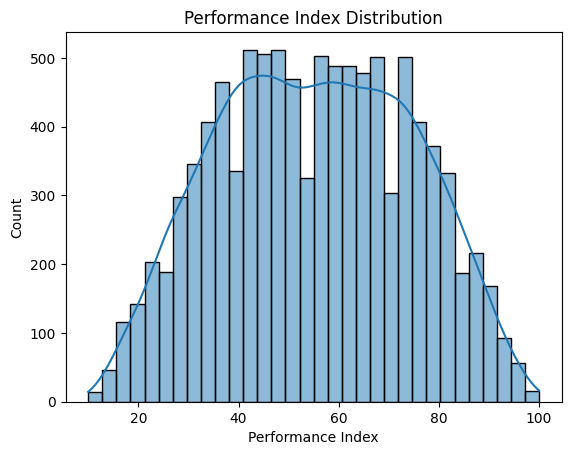

In [5]:
sns.histplot(df['Performance Index'], kde=True)
plt.title('Performance Index Distribution')
plt.show()

## Preprocessing

In [6]:
# Encode 'Extracurricular Activities'
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [7]:
# Split features and target
X = df.drop('Performance Index', axis=1)
y = df['Performance Index']
print(X.head())
print(y.head())

   Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
0              7               99                           1            9   
1              4               82                           0            4   
2              8               51                           1            7   
3              5               52                           1            5   
4              7               75                           0            8   

   Sample Question Papers Practiced  
0                                 1  
1                                 2  
2                                 2  
3                                 2  
4                                 5  
0    91.0
1    65.0
2    45.0
3    36.0
4    66.0
Name: Performance Index, dtype: float64


In [8]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (8000, 5)
X_test shape: (2000, 5)
y_train shape: (8000,)
y_test shape: (2000,)


In [9]:
# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
print(X_train_scaled_df.head())

   Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
0       0.006455        -1.183844                   -0.989307     0.269888   
1      -1.149747        -1.241506                    1.010808     0.269888   
2      -1.149747         0.661318                   -0.989307     0.269888   
3      -1.149747        -1.356828                   -0.989307    -0.318906   
4       1.162658        -1.299167                   -0.989307     1.447477   

   Sample Question Papers Practiced  
0                          0.134041  
1                          0.483562  
2                         -0.914520  
3                         -1.264041  
4                         -1.613561  


## Train and evaluate models

In [10]:
# Storage for results
results = []

In [11]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
results.append(['Linear Regression', r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred), np.sqrt(mean_squared_error(y_test, y_pred))])

In [12]:
# Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
plr = LinearRegression()
plr.fit(X_train_poly, y_train)
y_pred = plr.predict(X_test_poly)
results.append(['Polynomial Regression', r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred), np.sqrt(mean_squared_error(y_test, y_pred))])

In [13]:
# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)
results.append(['Lasso Regression', r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred), np.sqrt(mean_squared_error(y_test, y_pred))])

In [14]:
# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
results.append(['Ridge Regression', r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred), np.sqrt(mean_squared_error(y_test, y_pred))])

In [15]:
# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
results.append(['Decision Tree Regressor', r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred), np.sqrt(mean_squared_error(y_test, y_pred))])

In [16]:
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
results.append(['Random Forest Regressor', r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred), np.sqrt(mean_squared_error(y_test, y_pred))])

## Compare Results

In [17]:
results_df = pd.DataFrame(results, columns=['Model', 'R2 Score', 'MAE', 'RMSE'])
results_df.sort_values(by='R2 Score', ascending=False)

,Model,R2 Score,MAE,RMSE
1,Polynomial Regression,0.988989,1.611523,2.020060
0,Linear Regression,0.988983,1.611121,2.020552
3,Ridge Regression,0.988982,1.611223,2.020696
2,Lasso Regression,0.988733,1.626729,2.043354
5,Random Forest Regressor,0.986079,1.814721,2.271308
4,Decision Tree Regressor,0.976220,2.337833,2.968618


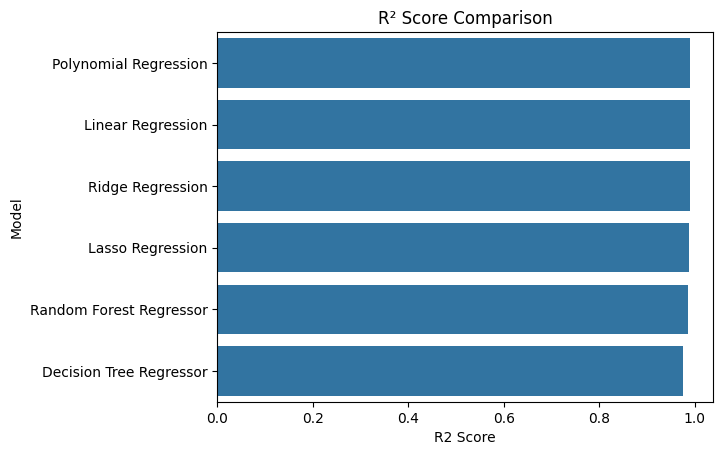

In [18]:
# Plot R2
sns.barplot(x='R2 Score', y='Model', data=results_df.sort_values(by='R2 Score', ascending=False))
plt.title('R² Score Comparison')
plt.show()

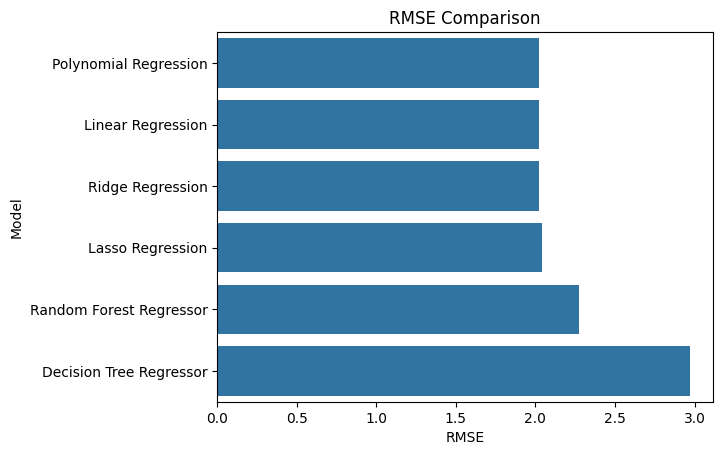

In [19]:
# Plot RMSE
sns.barplot(x='RMSE', y='Model', data=results_df.sort_values(by='RMSE'))
plt.title('RMSE Comparison')
plt.show()

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Define the threshold for passing
threshold = 50

# Create binary target column 'passed' based on Performance Index
df['passed'] = df['Performance Index'].apply(lambda x: 1 if x >= threshold else 0)

# Define features and target
X = df[['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
        'Sleep Hours', 'Sample Question Papers Practiced']]
y = df['passed']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize and train Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9705
Precision: 0.9760888129803587
Recall: 0.9735945485519591
F1-score: 0.9748400852878465
Confusion Matrix:
 [[ 798   28]
 [  31 1143]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.96       826
           1       0.98      0.97      0.97      1174

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000

